<a href="https://colab.research.google.com/github/Addreta/ctqw-mott-probe/blob/main/ctqw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install quspin

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.5/38.5 MB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 83.9 MB/s eta 0:00:00
  Created wheel for importlib: filename=importlib-1.0.4-py3-none-any.whl size=5850 sha256=29ce999a7d0f837d1184a93b2f91a80fcfa7b27f4cea5e75cba1f986cb146253
  Stored in directory: /root/.cache/pip/wheels/40/41/c4/d925a53b7b7e75a65369e1b17f7bade00d7907ac5a7d74dc5f
Successfully built importlib


In [ ]:
import numpy as np
from quspin.operators import hamiltonian
from quspin.basis import spinful_fermion_basis_1d

def compute_obdm(psi_gs, basis, L):
    """
    One-body density matrix: rho_ij = <GS| c†_i c_j |GS>
    Summed over both spins: rho_ij = rho_ij_up + rho_ij_down
    """
    obdm = np.zeros((L, L), dtype=float)

    for i in range(L):
        for j in range(L):
            # spin-up contribution: c†_i↑ c_j↑
            op_up = hamiltonian(
                [["+-", [[1.0, i, j]]]],   # c†_i c_j for up
                [], basis=basis, dtype=np.complex128,
                check_symm=False, check_herm=False
            )
            # spin-down contribution: c†_i↓ c_j↓
            op_dn = hamiltonian(
                [["+-", [[1.0, i, j]]]],   # same structure, down sector
                [], basis=basis, dtype=np.complex128,
                check_symm=False, check_herm=False
            )
            obdm[i, j] = (op_up.matrix_ele(psi_gs, psi_gs) +
                          op_dn.matrix_ele(psi_gs, psi_gs)).real
    return obdm

In [ ]:
def ctqw_centrality(A):
    """
    Long-time averaged occupation probability from adjacency matrix A.

    π_j = Σ_k  |<j|v_k>|²  |<v_k|ψ₀>|²

    Assumes non-degenerate spectrum (valid generically for OBDM).
    Initial state: uniform superposition over sites.
    """
    L = A.shape[0]
    eigenvalues, V = np.linalg.eigh(A)   # V[:,k] = k-th eigenvector

    psi0 = np.ones(L) / np.sqrt(L)       # uniform superposition
    c_k = V.T @ psi0                      # overlaps with eigenbasis

    # π_j = Σ_k |V[j,k]|² |c_k|²
    pi = np.einsum('jk,k->j', V**2, c_k**2)
    return pi

def spectral_gap(A):
    """Gap between two largest eigenvalues of adjacency matrix."""
    eigs = np.sort(np.linalg.eigvalsh(A))
    return eigs[-1] - eigs[-2]

def classical_eigenvector_centrality(A):
    """Eigenvector corresponding to largest eigenvalue."""
    eigs, vecs = np.linalg.eigh(A)
    return np.abs(vecs[:, -1])           # take absolute value

In [ ]:
import numpy as np
from quspin.operators import hamiltonian
from quspin.basis import spinful_fermion_basis_1d


# ==============================
# OBDM COMPUTATION (FIXED)
# ==============================
def compute_obdm(psi_gs, basis, L):
    rho = np.zeros((L, L), dtype=np.complex128)

    for i in range(L):
        for j in range(L):

            # Spin-up contribution: c†_{i↑} c_{j↑}
            op_up = hamiltonian(
                [["+-|", [[1.0, i, j]]]],
                [],
                basis=basis,
                dtype=np.complex128,
                check_herm=False,
                check_pcon=False
            )

            # Spin-down contribution: c†_{i↓} c_{j↓}
            op_dn = hamiltonian(
                [["|+-", [[1.0, i, j]]]],
                [],
                basis=basis,
                dtype=np.complex128,
                check_herm=False,
                check_pcon=False
            )

            # Expectation value
            rho[i, j] = (
                np.vdot(psi_gs, op_up.dot(psi_gs)) +
                np.vdot(psi_gs, op_dn.dot(psi_gs))
            )

    return rho


# ==============================
# CTQW ANALYSIS FUNCTIONS
# ==============================
def ctqw_centrality(rho):
    # normalize row-wise probability
    prob = np.abs(rho)**2
    pi = prob.sum(axis=1)
    return pi / np.sum(pi)


def spectral_gap(rho):
    eigvals = np.linalg.eigvalsh(rho)
    eigvals = np.sort(eigvals)
    return eigvals[-1] - eigvals[-2]


def classical_eigenvector_centrality(rho):
    A = np.abs(rho)
    vals, vecs = np.linalg.eig(A)
    idx = np.argmax(vals.real)
    v = np.abs(vecs[:, idx].real)
    return v / np.sum(v)


# ==============================
# SYSTEM PARAMETERS
# ==============================
L = 6
N_up = 3
N_dn = 3
t_hop = 1.0

U_over_t_values = np.array([0.5, 1.0, 2.0, 4.0, 6.0, 8.0, 12.0, 16.0])

results = []


# ==============================
# MAIN LOOP
# ==============================
for U_t in U_over_t_values:
    U = U_t * t_hop

    basis = spinful_fermion_basis_1d(L, Nf=(N_up, N_dn))

    # Hermitian hopping
    hop_right = [[-t_hop, i, i+1] for i in range(L-1)]
    hop_left  = [[+t_hop, i, i+1] for i in range(L-1)]

    inter_list = [[U, i, i] for i in range(L)]

    static = [
        ["+-|", hop_right], ["-+|", hop_left],   # spin-up
        ["|+-", hop_right], ["|-+", hop_left],   # spin-down
        ["n|n", inter_list]                      # interaction
    ]

    H = hamiltonian(static, [], basis=basis, dtype=np.float64)

    # Diagonalize
    E, V = H.eigh()
    psi_gs = V[:, 0]

    # OBDM
    rho = compute_obdm(psi_gs, basis, L)

    # CTQW-inspired analysis
    pi = ctqw_centrality(rho)
    gap = spectral_gap(rho)
    ec = classical_eigenvector_centrality(rho)

    results.append({
        'U_t': U_t,
        'obdm': rho,
        'ctqw_centrality': pi,
        'spectral_gap': gap,
        'classical_ec': ec,
        'ground_energy': E[0]
    })

print("Done.")

Hermiticity check passed!
Symmetry checks passed!
Particle conservation check passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Symmetry checks passed!
Sy

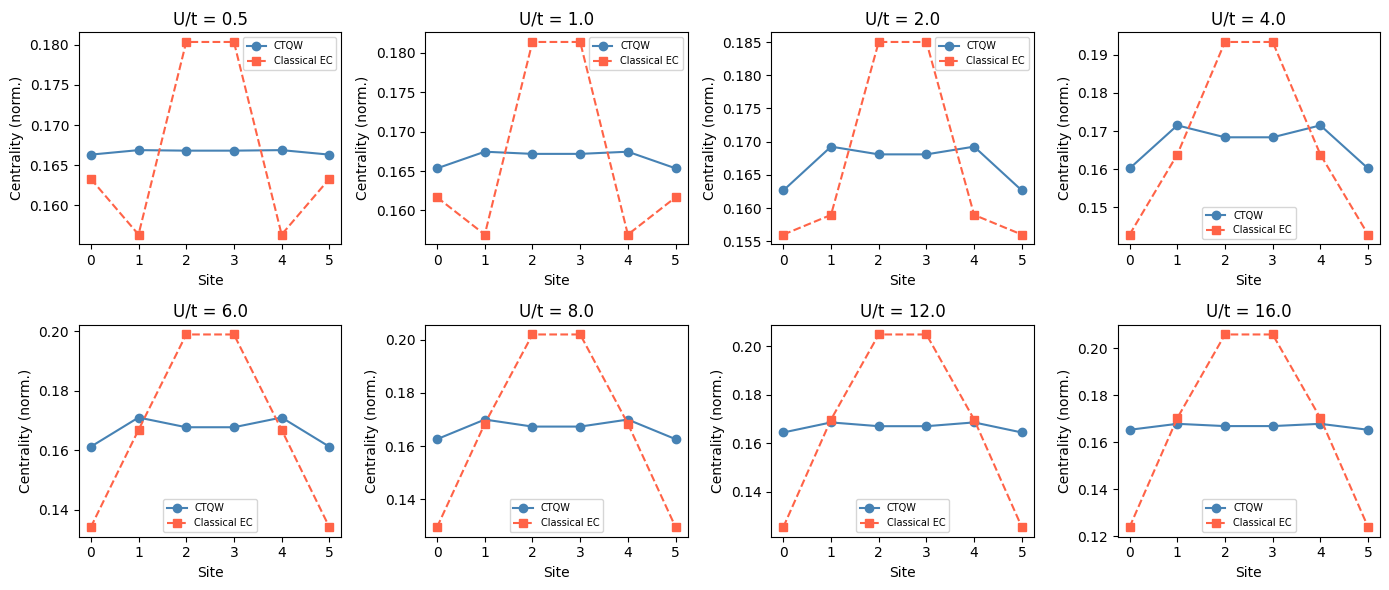

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharey=False)
sites = np.arange(L)

for ax, r in zip(axes.flat, results):
    ax.plot(sites, r['ctqw_centrality'], 'o-', label='CTQW', color='steelblue')
    ax.plot(sites, r['classical_ec'] / r['classical_ec'].sum(),
            's--', label='Classical EC', color='tomato')
    ax.set_title(f"U/t = {r['U_t']}")
    ax.set_xlabel("Site")
    ax.set_ylabel("Centrality (norm.)")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("centrality_profiles.png", dpi=150)

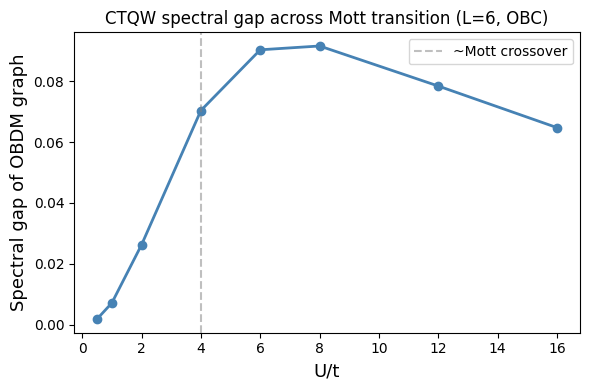

In [ ]:
gaps = [r['spectral_gap'] for r in results]
U_ts = [r['U_t'] for r in results]

plt.figure(figsize=(6, 4))
plt.plot(U_ts, gaps, 'o-', color='steelblue', linewidth=2)
plt.xlabel("U/t", fontsize=13)
plt.ylabel("Spectral gap of OBDM graph", fontsize=13)
plt.title("CTQW spectral gap across Mott transition (L=6, OBC)")
plt.axvline(x=4, linestyle='--', color='gray', alpha=0.5, label='~Mott crossover')
plt.legend()
plt.tight_layout()
plt.savefig("spectral_gap_vs_Ut.png", dpi=150)

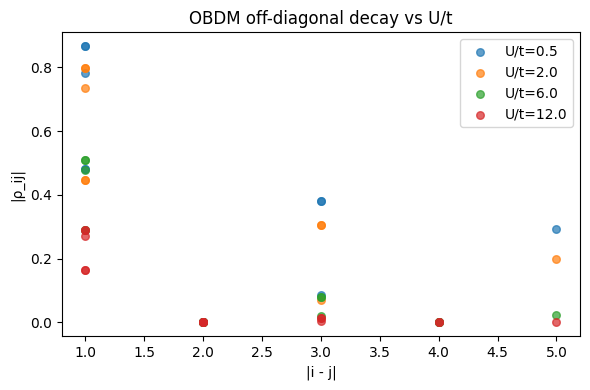

In [ ]:
# At each U/t, plot |ρ_ij| as a function of |i-j|
fig, ax = plt.subplots(figsize=(6, 4))
for r in results[::2]:   # every other U/t to avoid clutter
    rho = r['obdm']
    distances = []
    elements  = []
    for i in range(L):
        for j in range(i+1, L):
            distances.append(abs(i-j))
            elements.append(abs(rho[i,j]))
    ax.scatter(distances, elements, label=f"U/t={r['U_t']}", alpha=0.7, s=30)

ax.set_xlabel("|i - j|")
ax.set_ylabel("|ρ_ij|")
ax.set_title("OBDM off-diagonal decay vs U/t")
ax.legend()
plt.tight_layout()
plt.savefig("obdm_decay.png", dpi=150)

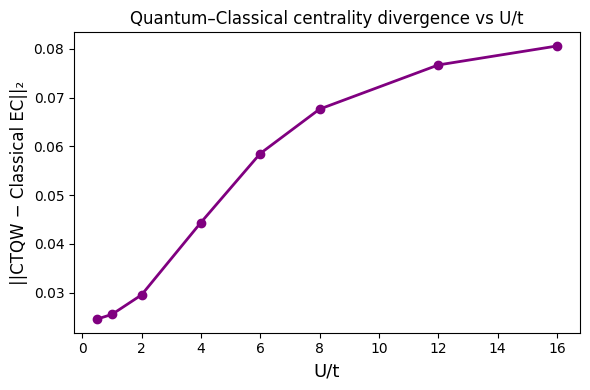

In [ ]:
# Divergence metric: how different are CTQW and classical EC?
from scipy.spatial.distance import euclidean

divergences = []
for r in results:
    pi   = r['ctqw_centrality']
    ec   = r['classical_ec'] / r['classical_ec'].sum()
    divergences.append(euclidean(pi, ec))

plt.figure(figsize=(6,4))
plt.plot(U_ts, divergences, 'o-', color='purple', linewidth=2)
plt.xlabel("U/t", fontsize=13)
plt.ylabel("||CTQW − Classical EC||₂", fontsize=12)
plt.title("Quantum–Classical centrality divergence vs U/t")
plt.tight_layout()
plt.savefig("centrality_divergence.png", dpi=150)